# MSME Customer Churn Prediction
## Predicting whether a B2B logistics customer will reorder the following month

**Context:** During my internship at Tata nexarc, I built cohort dashboards on customer 
transaction data and observed significant variation in MSME retention patterns across 
months. This project investigates which operational signals — delivery performance, 
LSP selection, SLA compliance, account type — best predict whether an MSME customer 
will place another order the following month.

**Dataset:** 9,500+ anonymised B2B logistics shipment records from Tata nexarc (July 2024)  
**Target:** Binary churn label — 0 = retained, 1 = churned  
**Overall churn rate:** 41.7%

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

print("All imports successful")

All imports successful


In [10]:
# Load clean data
df = pd.read_csv("C:/Users/anany/OneDrive/Desktop/Projects/Predicting MSME Churn from Logistics Signals/Data/msme_churn_clean.csv")

# Load label mappings
with open("C:/Users/anany/OneDrive/Desktop/Projects/Predicting MSME Churn from Logistics Signals/Data/label_mappings.json", 'r') as f:
    label_mappings = json.load(f)

print("Shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))

Shape: (5923, 12)

First 3 rows:
   LSP name  Overall SLA Compliance  Pick Up Compliance  \
0         1                       0                   1   
1         1                       0                   0   
2         1                       0                   0   

   Customer Order sequence  Key Accounts  Customer Status for the month  \
0                      1.0             1                              3   
1                      1.0             1                              3   
2                      1.0             1                              3   

   Total Delay Days  Pick up delay Days  Net Revenue  \
0               3.0                -5.0      1815.45   
1               0.0                -2.0       679.25   
2              -1.0                -3.0     14237.45   

   Total Actual Weight (kg)  Total goods Invoice Value  churned  
0                      50.0                    44800.0        1  
1                      40.0                    30711.0        1  
2     

In [11]:
# Separate features (X) from target (y)
# X = everything the model uses to predict
# y = what we're trying to predict (churned or not)

X = df.drop(columns=['churned'])
y = df['churned']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(list(X.columns))

Features shape: (5923, 11)
Target shape: (5923,)

Feature columns:
['LSP name', 'Overall SLA Compliance', 'Pick Up Compliance', 'Customer Order sequence', 'Key Accounts', 'Customer Status for the month', 'Total Delay Days', 'Pick up delay Days', 'Net Revenue', 'Total Actual Weight (kg)', 'Total goods Invoice Value']


## Model Preparation
Scaling numeric features so large-value columns (invoice value in lakhs) 
don't dominate over small-value columns (delay days). Splitting 80/20 into 
train and test sets with a fixed random seed for reproducibility.

In [12]:
# Scale numeric columns so they're all on the same range
# Without this, Invoice Value (in lakhs) dominates over Delay Days (single digits)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and test sets
# test_size=0.2 means 80% train, 20% test
# random_state=42 means the split is reproducible — same split every time you run it
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nChurn rate in training set:", round(y_train.mean() * 100, 1), "%")
print("Churn rate in test set:", round(y_test.mean() * 100, 1), "%")

Training set size: (4738, 11)
Test set size: (1185, 11)

Churn rate in training set: 41.8 %
Churn rate in test set: 41.1 %


## Logistic Regression Model
Logistic regression chosen for interpretability — coefficients directly 
tell us which features increase or decrease churn risk, making findings 
explainable to a non-technical stakeholder.

`class_weight='balanced'` accounts for the slight class imbalance 
(58% retained vs 42% churned).

In [13]:
# Train the logistic regression model
# max_iter=1000 gives the model enough iterations to converge
# class_weight='balanced' tells the model to account for the fact that
# we have more retained customers than churned ones
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully")

# Now predict on the test set
y_pred = model.predict(X_test)

# Evaluate
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

Model trained successfully

Classification Report:
              precision    recall  f1-score   support

    Retained       0.74      0.68      0.71       698
     Churned       0.59      0.66      0.62       487

    accuracy                           0.67      1185
   macro avg       0.67      0.67      0.67      1185
weighted avg       0.68      0.67      0.67      1185



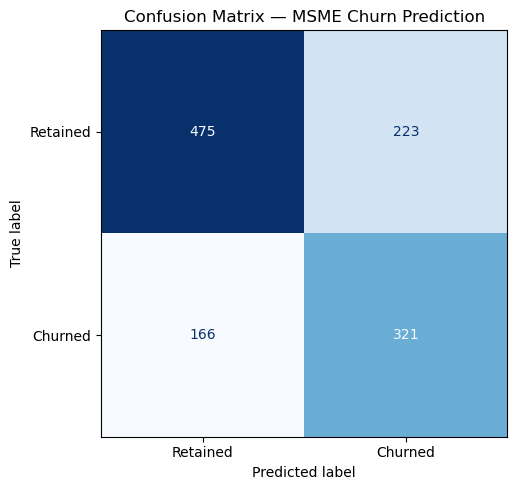

Saved to outputs/


In [15]:
# Confusion matrix — shows exactly where the model is right and wrong
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — MSME Churn Prediction')
plt.tight_layout()
plt.savefig("C:/Users/anany/OneDrive/Desktop/Projects/Predicting MSME Churn from Logistics Signals/Outputs/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

## Feature Importance
Model coefficients interpreted as churn drivers. Positive coefficient = 
feature increases churn risk. Negative coefficient = feature reduces churn risk.

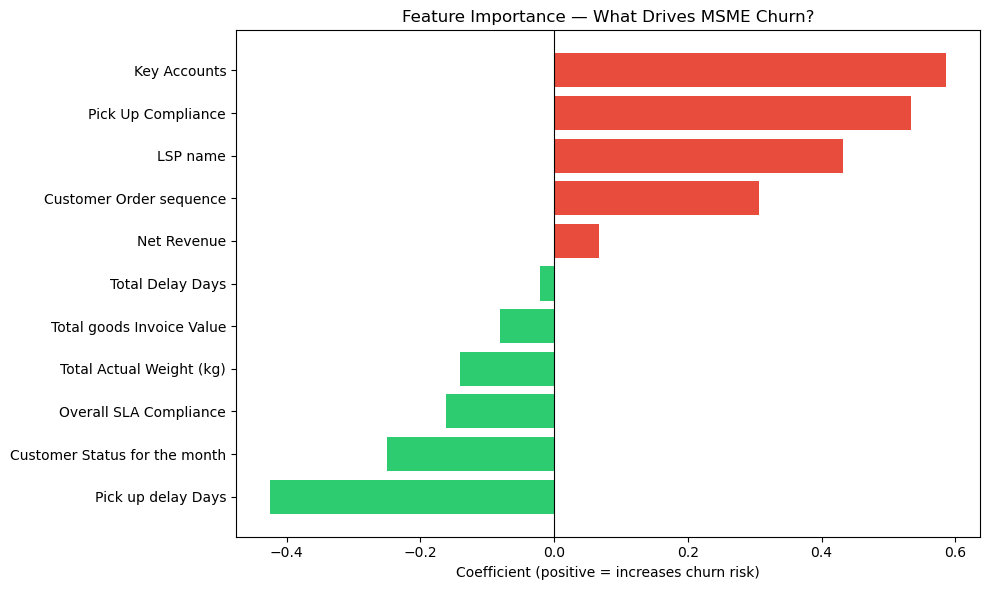

Saved to outputs/


In [17]:
# Feature importance from model coefficients
feature_names = list(df.drop(columns=['churned']).columns)
coefficients = model.coef_[0]

# Create a dataframe of features and their coefficients
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in importance_df['Coefficient']]
bars = ax.barh(importance_df['Feature'], importance_df['Coefficient'], color=colors)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Feature Importance — What Drives MSME Churn?')
ax.set_xlabel('Coefficient (positive = increases churn risk)')
plt.tight_layout()
plt.savefig("C:/Users/anany/OneDrive/Desktop/Projects/Predicting MSME Churn from Logistics Signals/Outputs/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

## Risk Tier Segmentation
Churn probabilities bucketed into three actionable tiers for operational use:
- **High Risk (>0.6):** Immediate outreach recommended
- **Medium Risk (0.3-0.6):** Monitor and engage proactively  
- **Low Risk (<0.3):** Minimal intervention needed

In [20]:
import pickle

# Save the model
with open("C:/Users/anany/OneDrive/Desktop/Projects/Predicting MSME Churn from Logistics Signals/Outputs/churn_model.pkl", 'wb') as f:
    pickle.dump(model, f)

# Export predictions for Power BI
# Get churn probability for every customer in test set
churn_proba = model.predict_proba(X_test)[:, 1]

# Create results dataframe
results_df = pd.DataFrame({
    'actual_churned': y_test.values,
    'predicted_churned': y_pred,
    'churn_probability': churn_proba.round(3)
})

# Add risk tier based on probability
results_df['risk_tier'] = pd.cut(
    results_df['churn_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print(results_df['risk_tier'].value_counts())
print("\nSample:")
print(results_df.head())

# Save for Power BI
results_df.to_csv("C:/Users/anany/OneDrive/Desktop/Projects/Predicting MSME Churn from Logistics Signals/Outputs/churn_predictions.csv", index=False)
print("\nSaved churn_predictions.csv")

risk_tier
Medium Risk    555
High Risk      369
Low Risk       261
Name: count, dtype: int64

Sample:
   actual_churned  predicted_churned  churn_probability    risk_tier
0               0                  0              0.295     Low Risk
1               0                  0              0.452  Medium Risk
2               1                  1              0.662    High Risk
3               1                  1              0.595  Medium Risk
4               1                  1              0.887    High Risk

Saved churn_predictions.csv


## Model Summary and Business Recommendations

**Model performance:** 67% accuracy, 66% recall on churned customers

**Top churn drivers (in order of importance):**
1. Non-key account status
2. Pickup compliance failure
3. LSP selection (V-XPRESS and OXYZEN highest risk)
4. Low order sequence (new customers)

**Recommended interventions:**
- Flag all first-order non-key account customers as high risk immediately
- Prioritise GATI or DELHIVERY for new customer shipments
- Trigger proactive outreach when pickup compliance fails on order 1 or 2
- Build a key account fast-track programme for high-potential new MSMEs

In [22]:
# Create a comprehensive export for Power BI
# We need readable labels, not encoded numbers

# Start with the test set features
X_test_df = pd.DataFrame(X_test, columns=df.drop(columns=['churned']).columns)

# Reload original unscaled test data for readable values
# We need to go back to df and get the test indices
df_reset = df.reset_index(drop=True)
test_indices = y_test.index

powerbi_df = df_reset.loc[test_indices].copy()

# Add predictions
powerbi_df['churn_probability'] = churn_proba.round(3)
powerbi_df['predicted_churned'] = y_pred
powerbi_df['actual_churned'] = y_test.values
powerbi_df['risk_tier'] = results_df['risk_tier'].values

# Map encoded values back to readable labels
lsp_map = {v: k for k, v in label_mappings['LSP name'].items()}
sla_map = {v: k for k, v in label_mappings['Overall SLA Compliance'].items()}
ka_map = {v: k for k, v in label_mappings['Key Accounts'].items()}
status_map = {v: k for k, v in label_mappings['Customer Status for the month'].items()}

powerbi_df['LSP name'] = powerbi_df['LSP name'].astype(str).map(label_mappings['LSP name'])
powerbi_df['Overall SLA Compliance'] = powerbi_df['Overall SLA Compliance'].astype(str).map(label_mappings['Overall SLA Compliance'])
powerbi_df['Key Accounts'] = powerbi_df['Key Accounts'].astype(str).map(label_mappings['Key Accounts'])
powerbi_df['Customer Status for the month'] = powerbi_df['Customer Status for the month'].astype(str).map(label_mappings['Customer Status for the month'])

print("Shape:", powerbi_df.shape)
print("\nSample:")
print(powerbi_df.head(3))

powerbi_df.to_csv("C:/Users/anany/OneDrive/Desktop/Projects/Predicting MSME Churn from Logistics Signals/Outputs/powerbi_export.csv", index=False)
print("\nSaved powerbi_export.csv")

Shape: (1185, 16)

Sample:
       LSP name Overall SLA Compliance  Pick Up Compliance  \
2333  DELHIVERY          Non-Compliant                   1   
1268       GATI              Compliant                   0   
5382    Unknown              Compliant                   0   

      Customer Order sequence     Key Accounts Customer Status for the month  \
2333                    194.0      Key Account                      Retained   
1268                      6.0  Non Key Account                      Retained   
5382                      6.0  Non Key Account                      Retained   

      Total Delay Days  Pick up delay Days  Net Revenue  \
2333              10.0                10.0       4454.1   
1268              -1.0                -1.0       3304.8   
5382              -1.0                -1.0        763.0   

      Total Actual Weight (kg)  Total goods Invoice Value  churned  \
2333                     185.0                    73185.0        0   
1268                     2